# train_gnn

Ten notebook robi dwa etapy:
1. sanity check: overfit na bardzo małym zbiorze `train_random_tiny.csv`
2. pełny trening baseline GNN na:
   - random split
   - scaffold split


## 1. Importy

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from gnn_model import (
    GCNRegressor,
    dataframe_to_graphs,
    evaluate,
    fit_model,
    init_linear_weights,
    make_graph_dataloader,
    set_seed,
)

DATA_DIR = Path("prepared_data")
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed(SEED)
print("Device:", DEVICE)


Device: cpu


## 2. Wczytanie plików

In [4]:
train_random_tiny = pd.read_csv(DATA_DIR / "train_random_tiny.csv")

train_random = pd.read_csv(DATA_DIR / "train_random.csv")
val_random = pd.read_csv(DATA_DIR / "val_random.csv")
test_random = pd.read_csv(DATA_DIR / "test_random.csv")

train_scaffold = pd.read_csv(DATA_DIR / "train_scaffold.csv")
val_scaffold = pd.read_csv(DATA_DIR / "val_scaffold.csv")
test_scaffold = pd.read_csv(DATA_DIR / "test_scaffold.csv")

print("tiny:", train_random_tiny.shape)
print("random train/val/test:", train_random.shape, val_random.shape, test_random.shape)
print("scaffold train/val/test:", train_scaffold.shape, val_scaffold.shape, test_scaffold.shape)


tiny: (128, 9)
random train/val/test: (7520, 9) (940, 9) (940, 9)
scaffold train/val/test: (7520, 10) (940, 10) (940, 10)


## 3. Featuryzacja tiny subsetu do grafów

In [5]:
tiny_graphs, tiny_valid = dataframe_to_graphs(
    train_random_tiny,
    smiles_col="canonical_smiles",
    target_col="y",
)

print("Tiny valid rows:", tiny_valid.shape)
print("Tiny graphs:", len(tiny_graphs))
print("Node feature dim:", tiny_graphs[0].x.shape[1])


Tiny valid rows: (128, 9)
Tiny graphs: 128
Node feature dim: 11


## 4. Overfit sanity check na tiny subset

In [6]:
tiny_loader = make_graph_dataloader(
    tiny_graphs,
    batch_size=min(32, len(tiny_graphs)),
    shuffle=True,
)

tiny_model = GCNRegressor(
    input_dim=tiny_graphs[0].x.shape[1],
    hidden_dim=64,
    dropout=0.0,
)
tiny_model.apply(init_linear_weights)

tiny_model, tiny_history = fit_model(
    tiny_model,
    tiny_loader,
    tiny_loader,
    epochs=200,
    lr=1e-3,
    weight_decay=0.0,
    device=DEVICE,
    verbose=True,
)

tiny_history.tail()


Epoch 001 | train_loss=40.6813 | val_loss=30.2402 | train_rmse=6.3782 | val_rmse=5.4991
Epoch 002 | train_loss=25.0255 | val_loss=17.5277 | train_rmse=5.0026 | val_rmse=4.1866
Epoch 003 | train_loss=13.6689 | val_loss=7.9559 | train_rmse=3.6971 | val_rmse=2.8206
Epoch 004 | train_loss=5.3606 | val_loss=2.0948 | train_rmse=2.3153 | val_rmse=1.4473
Epoch 005 | train_loss=1.4577 | val_loss=1.6382 | train_rmse=1.2073 | val_rmse=1.2799
Epoch 006 | train_loss=2.4003 | val_loss=3.3374 | train_rmse=1.5493 | val_rmse=1.8269
Epoch 007 | train_loss=3.2491 | val_loss=2.6419 | train_rmse=1.8025 | val_rmse=1.6254
Epoch 008 | train_loss=2.1900 | val_loss=1.4037 | train_rmse=1.4799 | val_rmse=1.1848
Epoch 009 | train_loss=1.2622 | val_loss=1.2774 | train_rmse=1.1235 | val_rmse=1.1302
Epoch 010 | train_loss=1.3982 | val_loss=1.5374 | train_rmse=1.1825 | val_rmse=1.2399
Epoch 011 | train_loss=1.5413 | val_loss=1.4729 | train_rmse=1.2415 | val_rmse=1.2136
Epoch 012 | train_loss=1.4116 | val_loss=1.2773 |

,epoch,train_loss,train_rmse,train_mae,train_r2,val_loss,val_rmse,val_mae,val_r2
195,196,1.016859,1.008394,0.830048,0.131556,1.009296,1.004637,0.821797,0.138015
196,197,1.042503,1.021030,0.819972,0.109655,1.010442,1.005208,0.819257,0.137036
197,198,1.124087,1.060229,0.868429,0.039979,1.044081,1.021803,0.848124,0.108307
198,199,1.038240,1.018941,0.843049,0.113296,1.077979,1.038257,0.823315,0.079357
199,200,1.061535,1.030308,0.826714,0.093400,1.025581,1.012710,0.837896,0.124107


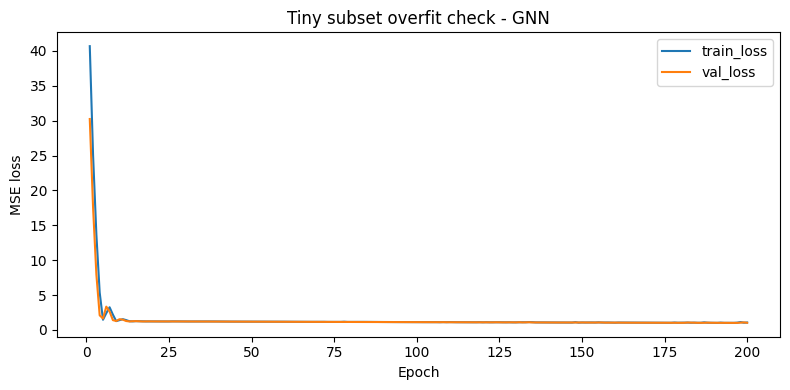

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(tiny_history["epoch"], tiny_history["train_loss"], label="train_loss")
plt.plot(tiny_history["epoch"], tiny_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Tiny subset overfit check - GNN")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Featuryzacja random split do grafów

In [8]:
train_graphs_r, train_random_valid = dataframe_to_graphs(train_random)
val_graphs_r, val_random_valid = dataframe_to_graphs(val_random)
test_graphs_r, test_random_valid = dataframe_to_graphs(test_random)

print(len(train_graphs_r), len(val_graphs_r), len(test_graphs_r))
print("Node feature dim:", train_graphs_r[0].x.shape[1])


7520 940 940
Node feature dim: 11


## 6. Trening GNN na random split

In [9]:
train_loader_r = make_graph_dataloader(train_graphs_r, batch_size=64, shuffle=True)
val_loader_r = make_graph_dataloader(val_graphs_r, batch_size=256, shuffle=False)
test_loader_r = make_graph_dataloader(test_graphs_r, batch_size=256, shuffle=False)

model_random = GCNRegressor(
    input_dim=train_graphs_r[0].x.shape[1],
    hidden_dim=64,
    dropout=0.1,
)
model_random.apply(init_linear_weights)

model_random, history_random = fit_model(
    model_random,
    train_loader_r,
    val_loader_r,
    epochs=50,
    lr=1e-3,
    weight_decay=0.0,
    device=DEVICE,
    verbose=True,
)

criterion = torch.nn.MSELoss()
test_random_result = evaluate(model_random, test_loader_r, criterion, DEVICE)
test_random_result


Epoch 001 | train_loss=6.5588 | val_loss=1.4477 | train_rmse=2.5610 | val_rmse=1.2032
Epoch 002 | train_loss=2.2437 | val_loss=1.4151 | train_rmse=1.4979 | val_rmse=1.1896
Epoch 003 | train_loss=2.1367 | val_loss=1.4532 | train_rmse=1.4617 | val_rmse=1.2055
Epoch 004 | train_loss=2.1033 | val_loss=1.3853 | train_rmse=1.4503 | val_rmse=1.1770
Epoch 005 | train_loss=2.0445 | val_loss=1.3693 | train_rmse=1.4299 | val_rmse=1.1702
Epoch 006 | train_loss=2.0240 | val_loss=1.3726 | train_rmse=1.4227 | val_rmse=1.1716
Epoch 007 | train_loss=1.9999 | val_loss=1.3553 | train_rmse=1.4142 | val_rmse=1.1642
Epoch 008 | train_loss=2.0143 | val_loss=1.3324 | train_rmse=1.4193 | val_rmse=1.1543
Epoch 009 | train_loss=1.9972 | val_loss=1.3671 | train_rmse=1.4132 | val_rmse=1.1692
Epoch 010 | train_loss=1.9735 | val_loss=1.3233 | train_rmse=1.4048 | val_rmse=1.1503
Epoch 011 | train_loss=1.9623 | val_loss=1.4012 | train_rmse=1.4008 | val_rmse=1.1837
Epoch 012 | train_loss=1.9840 | val_loss=1.3654 | trai

EpochResult(loss=1.1454167776919426, rmse=1.0702413827700243, mae=0.8591055274009705, r2=0.1782578607305204)

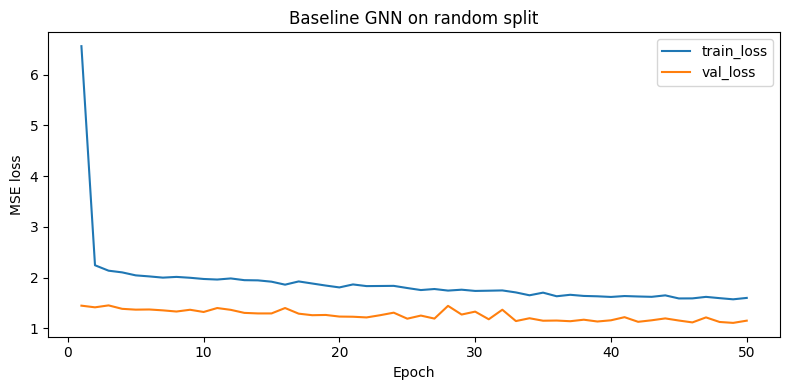

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history_random["epoch"], history_random["train_loss"], label="train_loss")
plt.plot(history_random["epoch"], history_random["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Baseline GNN on random split")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Featuryzacja scaffold split do grafów

In [11]:
train_graphs_s, train_scaffold_valid = dataframe_to_graphs(train_scaffold)
val_graphs_s, val_scaffold_valid = dataframe_to_graphs(val_scaffold)
test_graphs_s, test_scaffold_valid = dataframe_to_graphs(test_scaffold)

print(len(train_graphs_s), len(val_graphs_s), len(test_graphs_s))
print("Node feature dim:", train_graphs_s[0].x.shape[1])


7520 940 940
Node feature dim: 11


## 8. Trening GNN na scaffold split

In [12]:
train_loader_s = make_graph_dataloader(train_graphs_s, batch_size=64, shuffle=True)
val_loader_s = make_graph_dataloader(val_graphs_s, batch_size=256, shuffle=False)
test_loader_s = make_graph_dataloader(test_graphs_s, batch_size=256, shuffle=False)

model_scaffold = GCNRegressor(
    input_dim=train_graphs_s[0].x.shape[1],
    hidden_dim=64,
    dropout=0.1,
)
model_scaffold.apply(init_linear_weights)

model_scaffold, history_scaffold = fit_model(
    model_scaffold,
    train_loader_s,
    val_loader_s,
    epochs=50,
    lr=1e-3,
    weight_decay=0.0,
    device=DEVICE,
    verbose=True,
)

criterion = torch.nn.MSELoss()
test_scaffold_result = evaluate(model_scaffold, test_loader_s, criterion, DEVICE)
test_scaffold_result


Epoch 001 | train_loss=10.4532 | val_loss=1.5011 | train_rmse=3.2331 | val_rmse=1.2252
Epoch 002 | train_loss=2.4126 | val_loss=1.5164 | train_rmse=1.5532 | val_rmse=1.2314
Epoch 003 | train_loss=2.3068 | val_loss=1.4312 | train_rmse=1.5188 | val_rmse=1.1963
Epoch 004 | train_loss=2.3018 | val_loss=1.5237 | train_rmse=1.5172 | val_rmse=1.2344
Epoch 005 | train_loss=2.2600 | val_loss=1.4159 | train_rmse=1.5033 | val_rmse=1.1899
Epoch 006 | train_loss=2.2625 | val_loss=1.4532 | train_rmse=1.5042 | val_rmse=1.2055
Epoch 007 | train_loss=2.2391 | val_loss=1.4054 | train_rmse=1.4964 | val_rmse=1.1855
Epoch 008 | train_loss=2.2448 | val_loss=1.3784 | train_rmse=1.4983 | val_rmse=1.1740
Epoch 009 | train_loss=2.2210 | val_loss=1.3759 | train_rmse=1.4903 | val_rmse=1.1730
Epoch 010 | train_loss=2.1312 | val_loss=1.4810 | train_rmse=1.4599 | val_rmse=1.2170
Epoch 011 | train_loss=2.2185 | val_loss=1.4881 | train_rmse=1.4895 | val_rmse=1.2199
Epoch 012 | train_loss=2.2319 | val_loss=1.3619 | tra

EpochResult(loss=1.1622003210351821, rmse=1.0780539558333466, mae=0.8720436692237854, r2=0.13169060068052096)

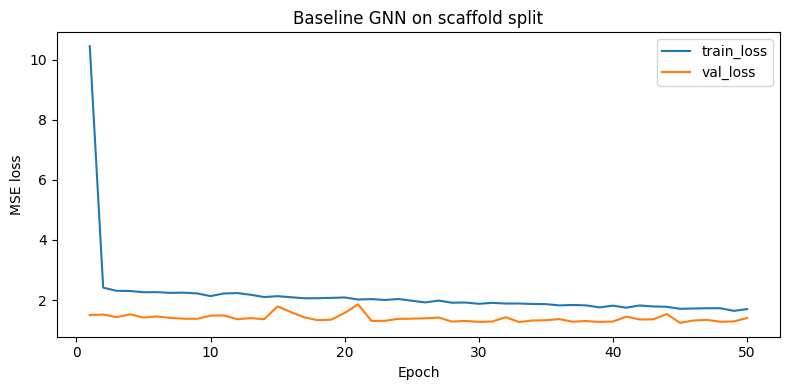

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(history_scaffold["epoch"], history_scaffold["train_loss"], label="train_loss")
plt.plot(history_scaffold["epoch"], history_scaffold["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Baseline GNN on scaffold split")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Porównanie końcowych wyników

In [14]:
results = pd.DataFrame([
    {
        "split": "random",
        "test_loss": test_random_result.loss,
        "test_rmse": test_random_result.rmse,
        "test_mae": test_random_result.mae,
        "test_r2": test_random_result.r2,
    },
    {
        "split": "scaffold",
        "test_loss": test_scaffold_result.loss,
        "test_rmse": test_scaffold_result.rmse,
        "test_mae": test_scaffold_result.mae,
        "test_r2": test_scaffold_result.r2,
    },
])

results


,split,test_loss,test_rmse,test_mae,test_r2
0,random,1.145417,1.070241,0.859106,0.178258
1,scaffold,1.162200,1.078054,0.872044,0.131691
